<a href="https://colab.research.google.com/github/han2109/Time-Series-Forecasting-ARIMA---US-Unemployment-Rate-/blob/main/B%E1%BA%A3n_sao_c%E1%BB%A7a_Mid_term_project_K224131622_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# Tải lên file train và test
uploaded = files.upload()

Saving CC4WSA - edited version.csv to CC4WSA - edited version.csv


The dataset used in this project is sourced from the U.S. Federal Reserve Economic Data (FRED) and contains weekly data on the 4-Week Moving Average of Continued Claims for unemployment insurance in the United States

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product
import warnings
warnings.filterwarnings("ignore")

Kích thước dataset: (3044, 1)

Tên và kiểu dữ liệu các cột:
CC4WSA    int64
dtype: object

5 dòng đầu tiên:
                   CC4WSA
observation_date         
1967-01-28        1118750
1967-02-04        1118000
1967-02-11        1126500
1967-02-18        1138500
1967-02-25        1162500


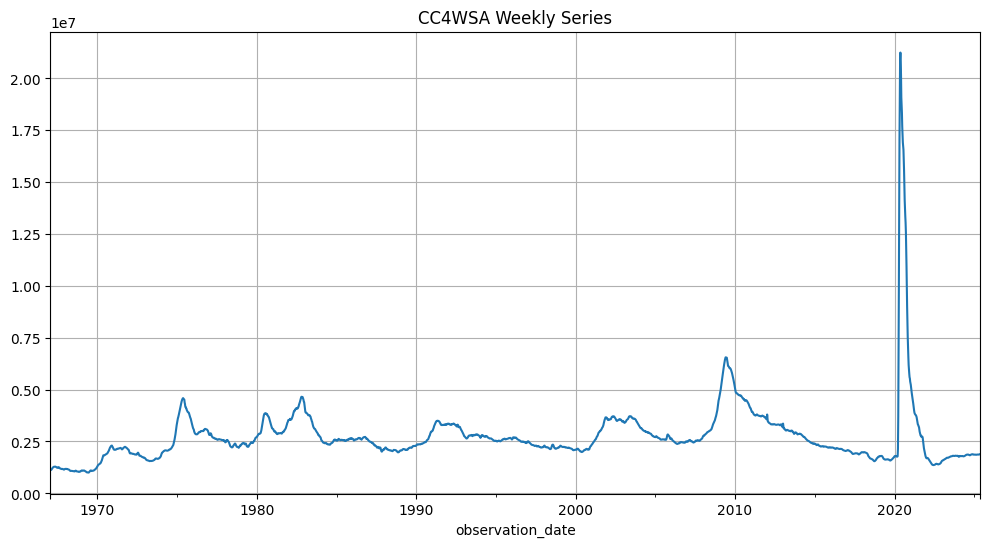

In [ ]:
# 1. Load & preprocess data
# ---------------------------

df = pd.read_csv("CC4WSA - edited version.csv", sep=";", encoding="utf-8")
df.columns = df.columns.str.strip()
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.set_index("observation_date", inplace=True)

# Tổng quan về dataset
print("Kích thước dataset:", df.shape)
print("\nTên và kiểu dữ liệu các cột:")
print(df.dtypes)
print("\n5 dòng đầu tiên:")
print(df.head())


# Weekly time series
ts = df["CC4WSA"].asfreq('W-SAT').fillna(method='ffill')

# Plot full series
ts.plot(title="CC4WSA Weekly Series", figsize=(12, 6))
plt.grid(True)
plt.show()

The time series of the 4-Week Moving Average of Continued Claims spans multiple decades, from the late 1960s to the present. As shown in the plot below, the series exhibits clear fluctuations over time, with sharp spikes during economic recessions — notably during the Great Recession of 2008–2009 and the COVID-19 pandemic in 2020, where claims peaked at an unprecedented level above 20 million

ADF Statistic: -5.749256695937747
p-value: 6.019730862336983e-07


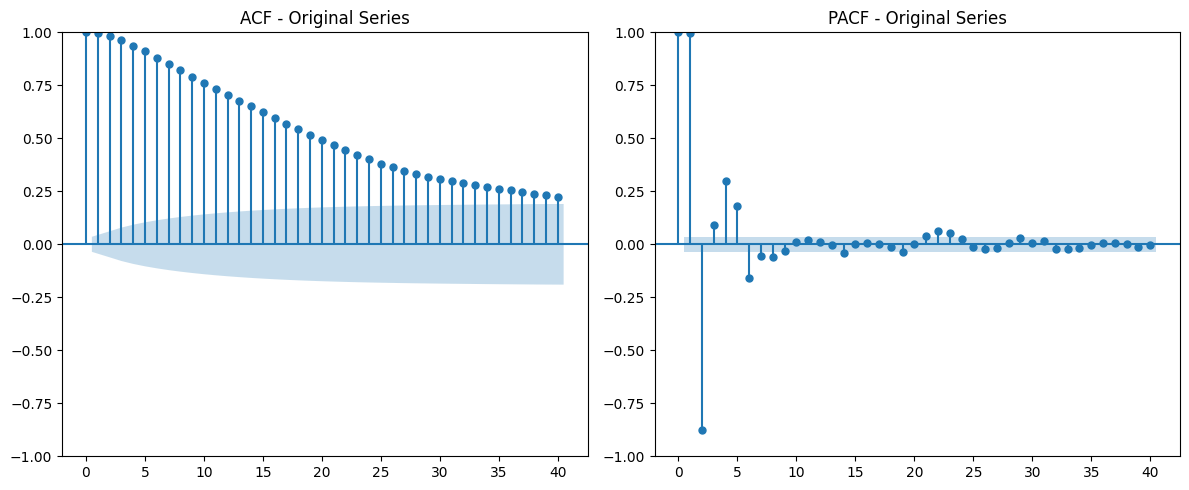

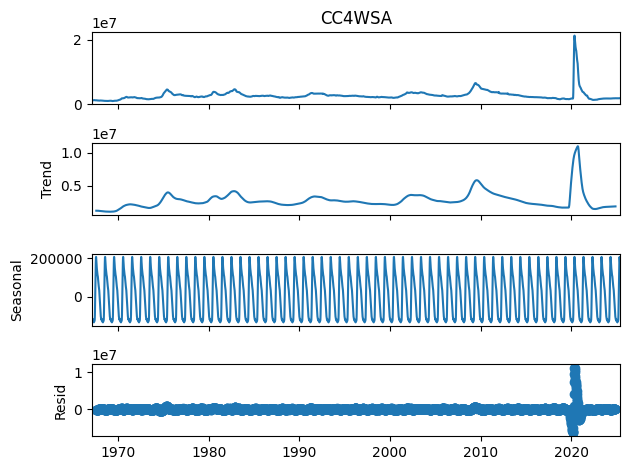

In [ ]:
# ADF test
adf_result = adfuller(ts.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# 📌 ACF & PACF for raw series
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(ts.dropna(), lags=40, ax=plt.gca())
plt.title("ACF - Original Series")
plt.subplot(1, 2, 2)
plot_pacf(ts.dropna(), lags=40, ax=plt.gca(), method='ywm')
plt.title("PACF - Original Series")
plt.tight_layout()
plt.show()

# Decomposition
seasonal_decompose(ts, model='additive', period=52).plot()
plt.show()

Since the p-value is well below 0.05, we reject the null hypothesis of non-stationarity. This means the series is stationary, or at least weakly stationary, without needing to apply differencing.
The strong seasonality observed in the full time series plot also implies the need for seasonal components, such as in SARIMA models with a 52-week seasonal period.

The decomposition confirms that the CC4WSA series consists of a long-term upward trend, a highly regular seasonal pattern, and a small residual component except during crisis periods. The COVID-19 shock introduced significant noise that exceeds what trend and seasonality can explain.

The stationarity of the series allows for direct modeling using seasonal time series models such as Holt-Winters and SARIMA, which assume stable behavior across time.

In [ ]:
# 2. Train-test split
# ---------------------------
train = ts[:-52]
test = ts[-52:]

Best SARIMA order: (1, 1, 1)
Best SARIMA seasonal order: (0, 1, 1, 52)


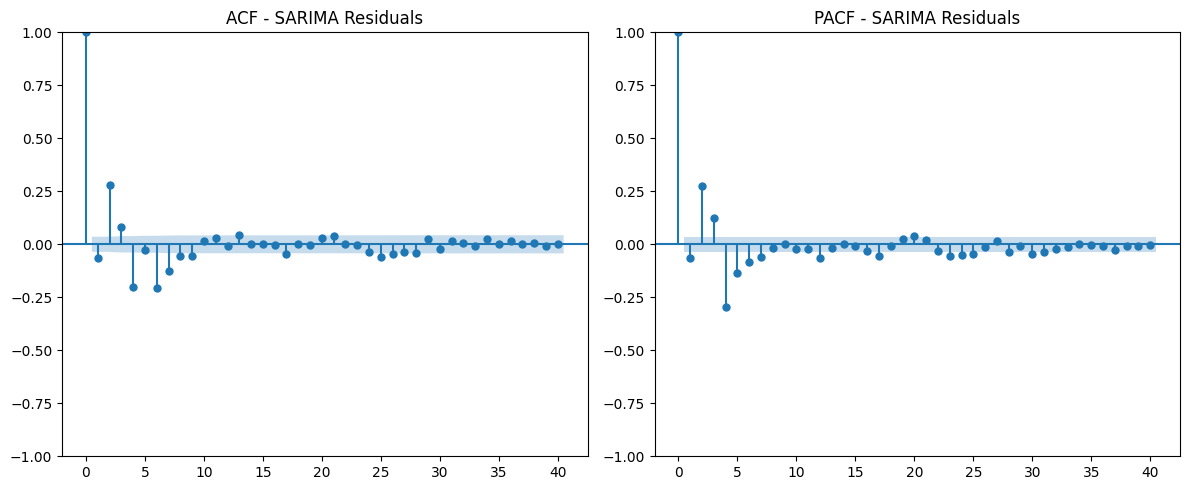

In [ ]:
# 3. Holt-Winters
# ---------------------------
hw_model = ExponentialSmoothing(train, seasonal='add', seasonal_periods=52).fit()
hw_forecast = hw_model.forecast(52)

# ---------------------------
# 4. SARIMA (grid search by AIC)
# ---------------------------
p = d = q = range(0, 2)
P = D = Q = range(0, 2)
m = 52
best_aic = np.inf
best_order = None
best_seasonal = None

for order in product(p, d, q):
    for seasonal in product(P, D, Q):
        seasonal_order = seasonal + (m,)
        try:
            model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal = seasonal_order
        except:
            continue

print("Best SARIMA order:", best_order)
print("Best SARIMA seasonal order:", best_seasonal)

sarima_model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal).fit()
sarima_forecast = sarima_model.get_forecast(52).predicted_mean

# 📌 ACF & PACF for SARIMA residuals
resid = sarima_model.resid

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(resid.dropna(), lags=40, ax=plt.gca())
plt.title("ACF - SARIMA Residuals")
plt.subplot(1, 2, 2)
plot_pacf(resid.dropna(), lags=40, ax=plt.gca(), method='ywm')
plt.title("PACF - SARIMA Residuals")
plt.tight_layout()
plt.show()

# ---------------------------
# 5. STL + ARIMA
# ---------------------------
stl = STL(train, seasonal=53)
res = stl.fit()
residual = res.resid

arima_model = ARIMA(residual, order=(1, 0, 1)).fit()
forecast_resid = arima_model.forecast(52)

In [ ]:
# Trend forecast
trend_last = res.trend[-1]
seasonal_pattern = res.seasonal[-53:-1].values[:52]
stl_forecast = trend_last + seasonal_pattern + forecast_resid.values


In [ ]:
# 6. Model evaluation
# ---------------------------
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

actual = test.values

for name, forecast in zip(["Holt-Winters", "SARIMA", "STL + ARIMA"],
                          [hw_forecast, sarima_forecast, stl_forecast]):
    forecast_array = np.array(forecast)
    print(f"\n{name}")
    mae = mean_absolute_error(actual, forecast_array)
    rmse = np.sqrt(mean_squared_error(actual, forecast_array))
    msv = np.mean(forecast_array ** 2)
    mape_val = mape(actual, forecast_array)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MSV (Mean Square Value):", msv)
    print("MAPE:", mape_val)


# ---------------------------
# 7. Plot forecast results
# ---------------------------
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, hw_forecast, label='Holt-Winters', color='red')
plt.plot(test.index, sarima_forecast, label='SARIMA', color='green')
plt.plot(test.index, stl_forecast, label='STL + ARIMA', color='purple')
plt.title("Forecast Comparison")
plt.legend()
plt.grid(True)
plt.show()

The Holt-Winters model outperforms both SARIMA and STL + ARIMA across all three evaluation metrics. It is particularly effective due to the nature of the data—strong trend and regular seasonality—which matches well with Holt-Winters' assumptions.

The black line (actual data) is relatively stable with a modest increase in the last months.
The red line (Holt-Winters) tracks this well, staying close to actual values.
The green (SARIMA) and purple (STL + ARIMA) lines diverge significantly, underestimating during the drop and overreacting in the rebound.


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
print(acorr_ljungbox(sarima_model.resid.dropna(), lags=[20], return_df=True))


       lb_stat      lb_pvalue
20  601.401122  1.458821e-114


*bổ sung ljungbox

Forecast for next 52 weeks (Holt-Winters):
2025-05-31    1.888194e+06
2025-06-07    1.891325e+06
2025-06-14    1.885673e+06
2025-06-21    1.880685e+06
2025-06-28    1.881378e+06
2025-07-05    1.880952e+06
2025-07-12    1.882023e+06
2025-07-19    1.880197e+06
2025-07-26    1.881197e+06
2025-08-02    1.887247e+06
2025-08-09    1.892050e+06
2025-08-16    1.900259e+06
2025-08-23    1.904433e+06
2025-08-30    1.904344e+06
2025-09-06    1.910798e+06
2025-09-13    1.909296e+06
2025-09-20    1.909901e+06
2025-09-27    1.913312e+06
2025-10-04    1.906420e+06
2025-10-11    1.908256e+06
2025-10-18    1.907268e+06
2025-10-25    1.902612e+06
2025-11-01    1.903193e+06
2025-11-08    1.900068e+06
2025-11-15    1.894721e+06
2025-11-22    1.893413e+06
2025-11-29    1.891027e+06
2025-12-06    1.890069e+06
2025-12-13    1.890429e+06
2025-12-20    1.889039e+06
2025-12-27    1.884099e+06
2026-01-03    1.880695e+06
2026-01-10    1.880026e+06
2026-01-17    1.880493e+06
2026-01-24    1.878261e+06
2026-01-31  

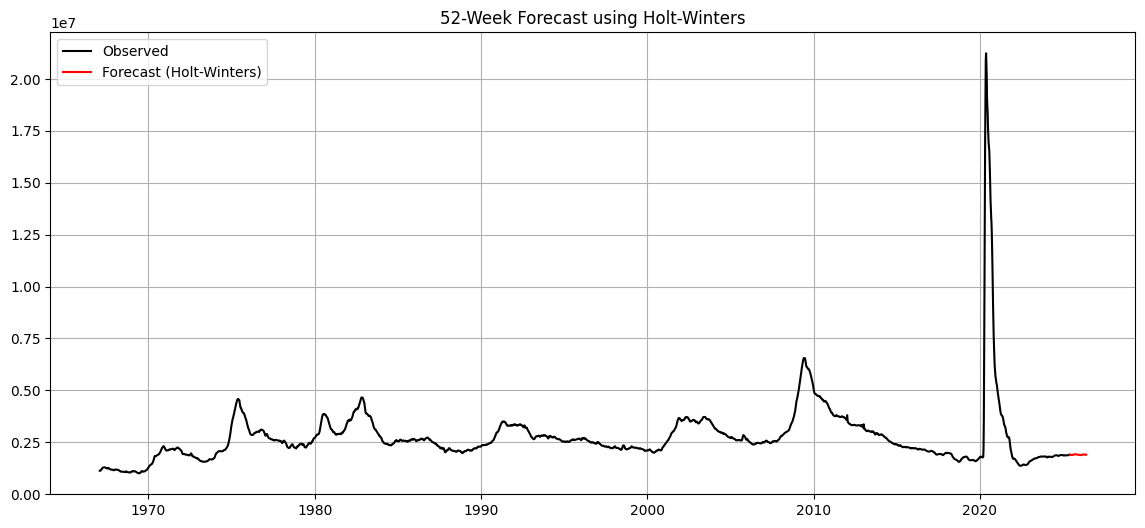

In [ ]:
# Fit mô hình Holt-Winters lên toàn bộ chuỗi thời gian
full_hw_model = ExponentialSmoothing(ts, seasonal='add', seasonal_periods=52).fit()

# Forecast 52 tuần tiếp theo
future_forecast = full_hw_model.forecast(52)

# In kết quả
print("Forecast for next 52 weeks (Holt-Winters):")
print(future_forecast)

# Vẽ biểu đồ
plt.figure(figsize=(14, 6))
plt.plot(ts, label='Observed', color='black')
plt.plot(future_forecast.index, future_forecast, label='Forecast (Holt-Winters)', color='red')
plt.title("52-Week Forecast using Holt-Winters")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("{:,.0f}".format(1.888194e+06))  # Kết quả: 1,888,194


1,888,194


In [ ]:
# Chuyển forecast thành DataFrame
forecast_df = future_forecast.reset_index()
forecast_df.columns = ['Date', 'Forecast']

# Lưu ra file CSV, đảm bảo không ghi dưới dạng khoa học
forecast_df.to_csv("holt_winters_forecast.csv", index=False, float_format='%.2f')


•	The red forecast line continues the current trend smoothly, showing no major shocks or volatility, which aligns with recent observations.
•	Seasonal patterns are clearly present, rising around August–October and early spring, in line with historical cycles in the labor market.
•	The forecast values remain stable in the range of 1.88 – 1.91 million, indicating economic stabilization in unemployment claims after the COVID-19 shock.


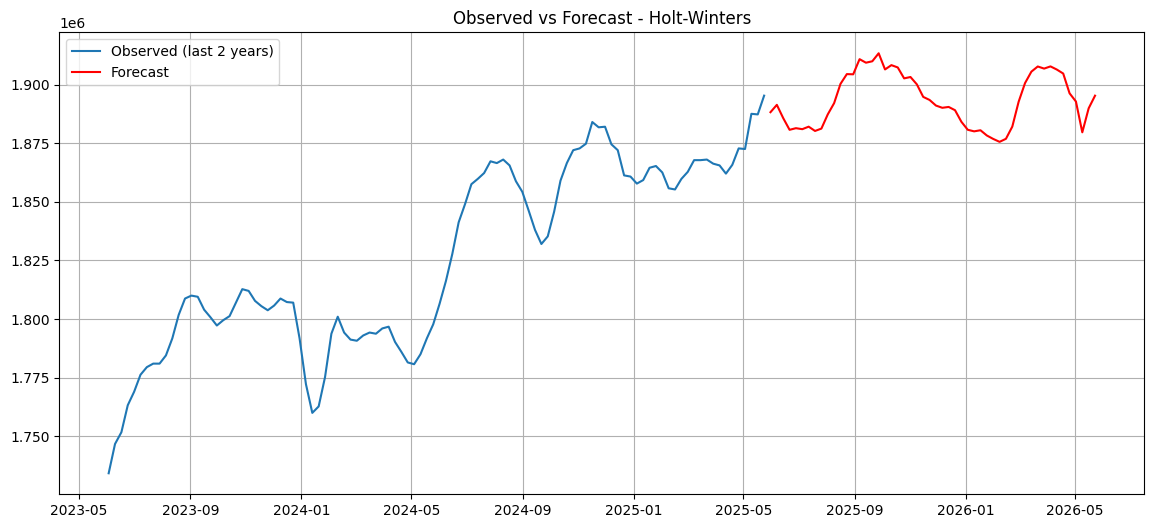

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(ts[-104:], label='Observed (last 2 years)')
plt.plot(future_forecast.index, future_forecast, label='Forecast', color='red')
plt.title("Observed vs Forecast - Holt-Winters")
plt.legend()
plt.grid(True)
plt.show()


This chart overlays the forecast (red) for 52 weeks ahead with the last two years of actual data (blue). It clearly shows how the model extends recent patterns into the future without overreacting to recent volatility

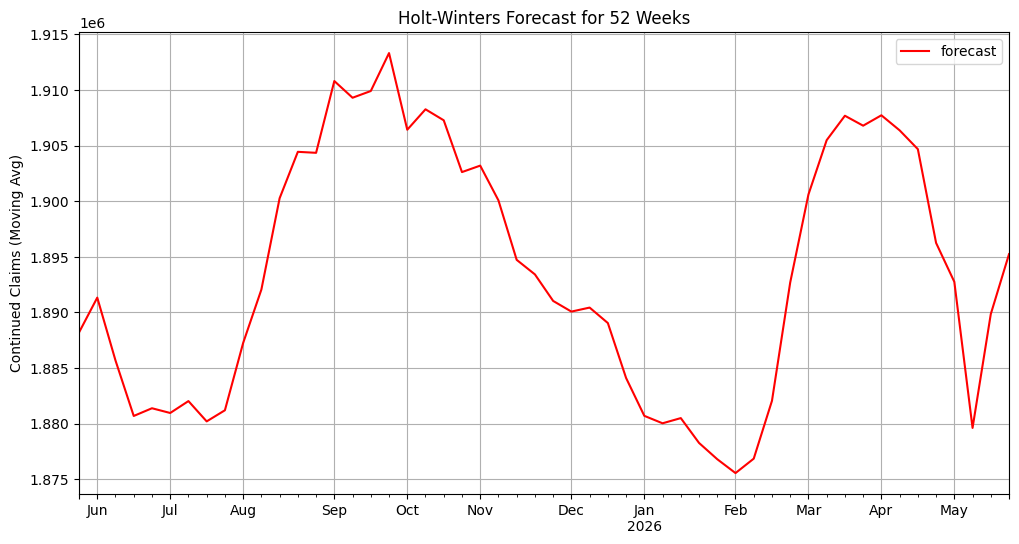

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

forecast = pd.read_csv("holt_winters_forecast.csv", index_col=0, parse_dates=True)

forecast.plot(figsize=(12,6), title="Holt-Winters Forecast for 52 Weeks", color='red')
plt.ylabel("Continued Claims (Moving Avg)")
plt.grid(True)
plt.show()


Peaks appear around September and March, while dips occur in June and January. This reflects the consistent cyclical nature of continued unemployment claims.

•	The periodic pattern captured by the model is consistent with historical behavior of unemployment insurance claims in the US, which are highly cyclical and seasonal.

REF : Stlouisfed.org. (2025). 4-Week Moving Average of Continued Claims (Insured Unemployment). [online] Available at: https://fred.stlouisfed.org/series/CC4WSA?utm_source=chatgpt.com [Accessed 23 Jun. 2025].